<a href="https://colab.research.google.com/github/TerradasExatas/Metodos_Matematicos/blob/main/Modelos_regressao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Atenção, este material é um apoio para estudantes que pretendem estudar formas diversas de regressão usando Machine Learning com foco em aplicações de Engenharia e Física. O Código utilizou o auxílio de IA para ser gerado. Case seja utilizado em trabalhos acadêmicos, deve ser citado.
Prof. Dennis L Toufen.

Bons estudos!

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

Train Loss (MSE): 0.0001
Test Loss (MSE - extrapolação): 0.0056


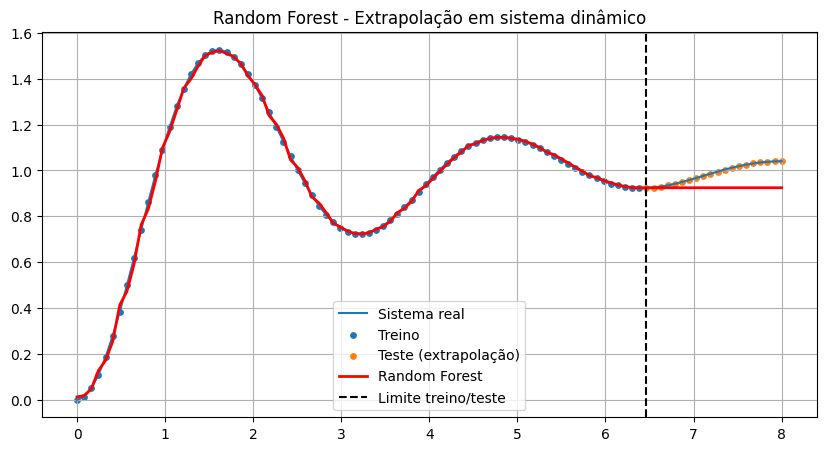

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# 1) Sistema 2ª ordem

t = np.linspace(0, 8, 100).reshape(-1,1)

zeta = 0.2
wn = 2.0
wd = wn * np.sqrt(1 - zeta**2)

y = 1 - (1/np.sqrt(1-zeta**2)) * np.exp(-zeta*wn*t) * np.sin(wd*t + np.arccos(zeta))

# 2) Split (80% treino / 20% extrapolação)

split_idx = int(0.8 * len(t))

X_train = t[:split_idx]
y_train = y[:split_idx]

X_test = t[split_idx:]
y_test = y[split_idx:]

# 3) Modelo

model = RandomForestRegressor(n_estimators=200)
model.fit(X_train, y_train.ravel())

# 4) Predições

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 5) Loss

train_loss = mean_squared_error(y_train, y_train_pred)
test_loss = mean_squared_error(y_test, y_test_pred)

print(f"Train Loss (MSE): {train_loss:.4f}")
print(f"Test Loss (MSE - extrapolação): {test_loss:.4f}")

# 6) Plot

X_all = t
y_all_pred = model.predict(X_all)

plt.figure(figsize=(10,5))

# real
plt.plot(t, y, label="Sistema real")

# treino
plt.scatter(X_train, y_train, s=15, label="Treino")

# teste (extrapolação)
plt.scatter(X_test, y_test, s=15, label="Teste (extrapolação)")

# modelo
plt.plot(X_all, y_all_pred, 'r', label="Random Forest", linewidth=2)

# divisão
plt.axvline(t[split_idx], linestyle='--', color='k', label="Limite treino/teste")

plt.title("Random Forest - Extrapolação em sistema dinâmico")
plt.legend()
plt.grid()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


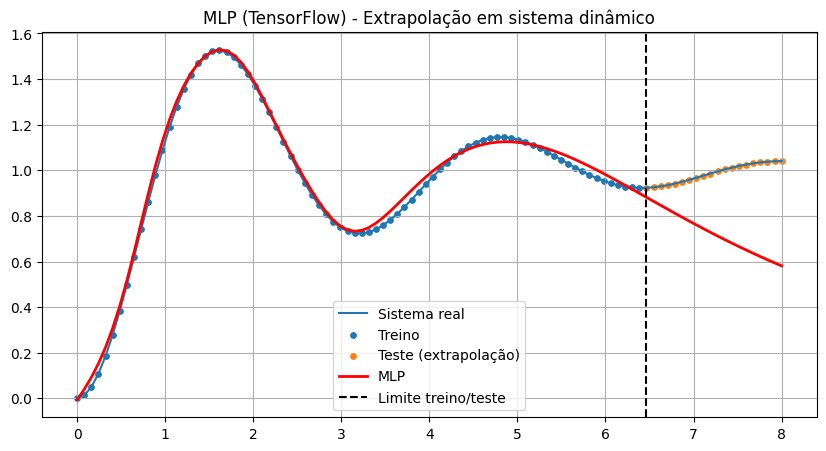

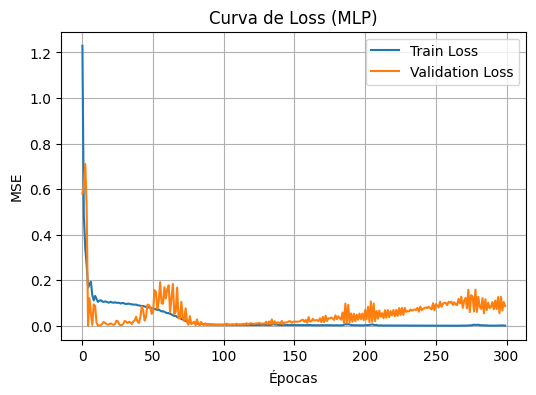

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

# 1) Sistema 2ª ordem

t = np.linspace(0, 8, 100).reshape(-1,1)

zeta = 0.2
wn = 2.0
wd = wn * np.sqrt(1 - zeta**2)

y = 1 - (1/np.sqrt(1-zeta**2)) * np.exp(-zeta*wn*t) * np.sin(wd*t + np.arccos(zeta))

# 2) Split

split_idx = int(0.8 * len(t))

X_train = t[:split_idx]
y_train = y[:split_idx]

X_test = t[split_idx:]
y_test = y[split_idx:]

# 3) Normalização

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4) Modelo MLP

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='tanh'),
    tf.keras.layers.Dense(64, activation='tanh'),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='mse'
)

# 5) Treinamento

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=300,
    verbose=0
)


# 6) Predição

X_all_scaled = scaler.transform(t)
y_pred = model.predict(X_all_scaled)

# 7) Plot regressão + extrapolação

plt.figure(figsize=(10,5))

plt.plot(t, y, label="Sistema real")

# treino
plt.scatter(X_train, y_train, s=15, label="Treino")

# teste (extrapolação)
plt.scatter(X_test, y_test, s=15, label="Teste (extrapolação)")

plt.plot(t, y_pred, 'r', label="MLP", linewidth=2)

# linha separadora
plt.axvline(t[split_idx], linestyle='--', color='k', label="Limite treino/teste")

plt.title("MLP (TensorFlow) - Extrapolação em sistema dinâmico")
plt.legend()
plt.grid()
plt.show()

# 8) Curva de Loss

plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.title("Curva de Loss (MLP)")
plt.legend()
plt.grid()
plt.show()

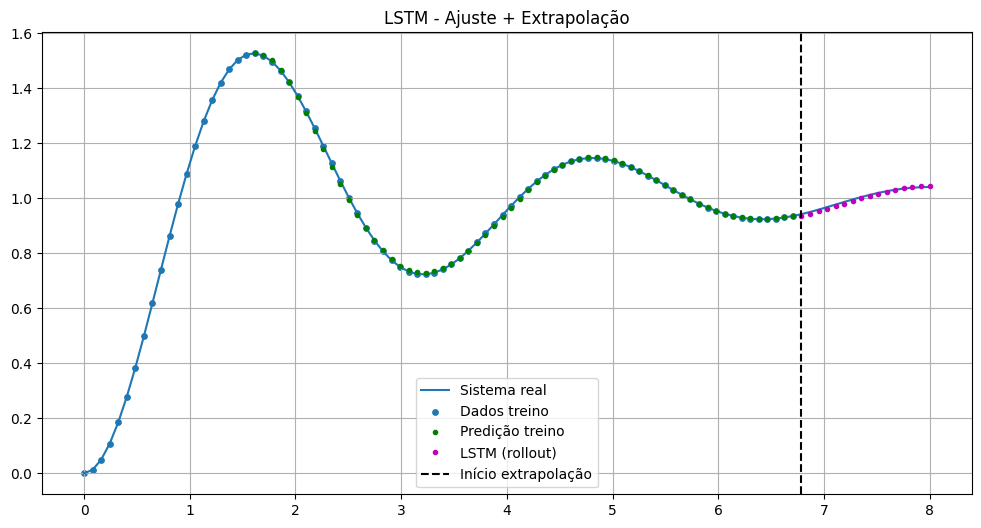

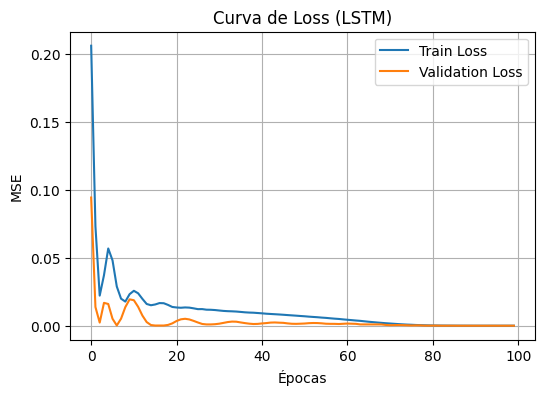

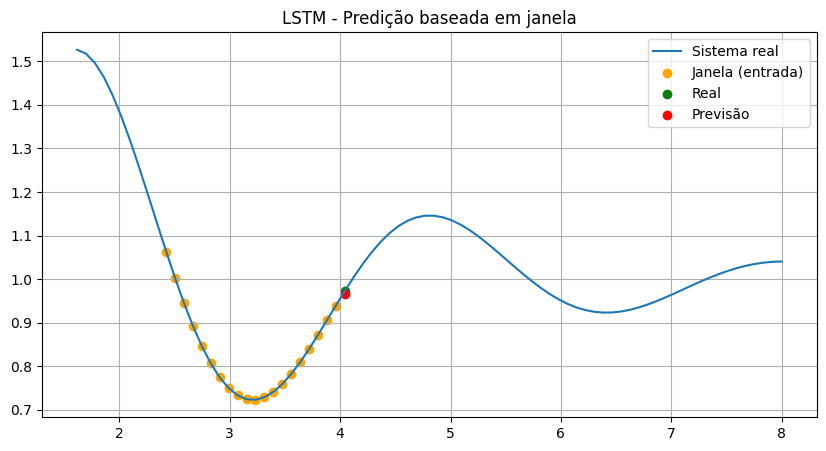

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

# 1) Sistema

t = np.linspace(0, 8, 100).reshape(-1,1)

zeta = 0.2
wn = 2.0
wd = wn * np.sqrt(1 - zeta**2)

y = 1 - (1/np.sqrt(1-zeta**2)) * np.exp(-zeta*wn*t) * np.sin(wd*t + np.arccos(zeta))
y = y.flatten()

# 2) Dataset

def create_dataset(series, window=20):
    X, y = [], []
    for i in range(len(series)-window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    return np.array(X), np.array(y)

window = 20
X_ts, y_ts = create_dataset(y, window)
X_ts = X_ts[..., np.newaxis]

# 3) Split

split_idx = int(0.8 * len(X_ts))

X_train = X_ts[:split_idx]
y_train = y_ts[:split_idx]

X_val = X_ts[split_idx:]
y_val = y_ts[split_idx:]

# 4) Modelo

model = tf.keras.Sequential([
    layers.LSTM(32, activation='tanh'),
    layers.Dense(8, activation='relu'),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# 5) Treinamento

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    verbose=0
)

# 6) Predição no treino

pred_train = model.predict(X_train, verbose=0).flatten()

# 7) Rollout (extrapolação)

current_window = X_train[-1].flatten()

pred_rollout = []

steps = len(y_ts) - split_idx

for _ in range(steps):
    input_seq = current_window.reshape(1, window, 1)

    next_pred = model.predict(input_seq, verbose=0)[0,0]

    pred_rollout.append(next_pred)

    current_window = np.append(current_window[1:], next_pred)

# 8) Tempo

t_targets = t[window:]

t_train = t_targets[:split_idx]
t_roll = t_targets[split_idx:]
t_split = t_targets[split_idx]

# 9) Plot principal

plt.figure(figsize=(12,6))

# sistema real
plt.plot(t, y, label="Sistema real")

# pontos reais de treino
plt.scatter(t[:window+split_idx], y[:window+split_idx], s=15, label="Dados treino")

# predição no treino
plt.plot(t_train, pred_train, 'g.', label="Predição treino")

# rollout
plt.plot(t_roll, pred_rollout, 'm.', label="LSTM (rollout)")

# divisão
plt.axvline(t_split, linestyle='--', color='k', label="Início extrapolação")

plt.title("LSTM - Ajuste + Extrapolação")
plt.legend()
plt.grid()
plt.show()

# 10) Loss

plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.title("Curva de Loss (LSTM)")
plt.legend()
plt.grid()
plt.show()

# 9) Destaque janela

idx = 30

plt.figure(figsize=(10,5))
y_real_targets = y[window:]
plt.plot(t_targets, y_real_targets, label="Sistema real")

t_window = t[idx:idx+window]
y_window = y[idx:idx+window]

t_target = t[idx+window]
y_target = y[idx+window]

plt.scatter(t_window, y_window, color='orange', label="Janela (entrada)")
plt.scatter(t_target, y_target, color='green', label="Real")
plt.scatter(t_target, pred_train[idx], color='red', label="Previsão")

plt.title("LSTM - Predição baseada em janela")
plt.legend()
plt.grid()
plt.show()

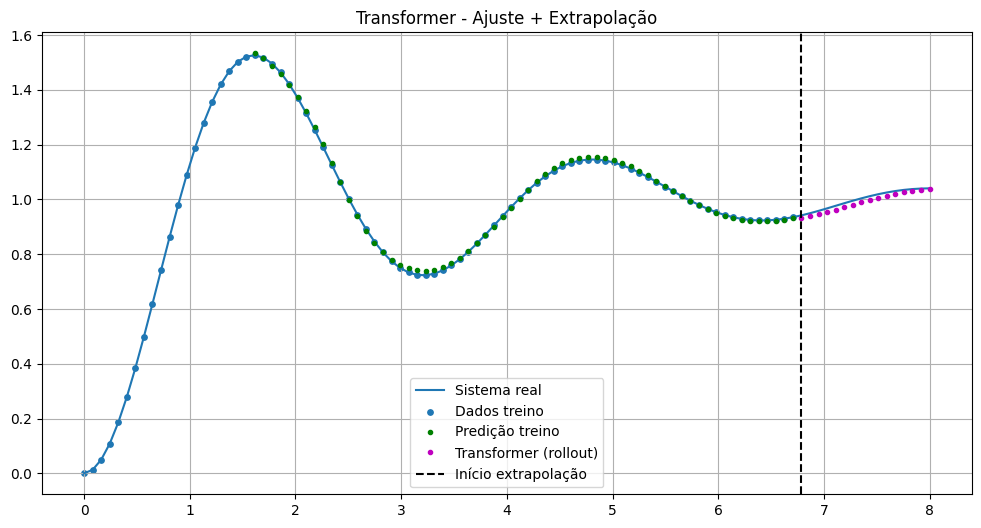

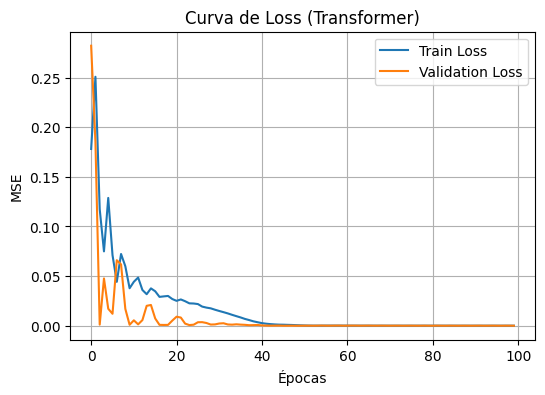

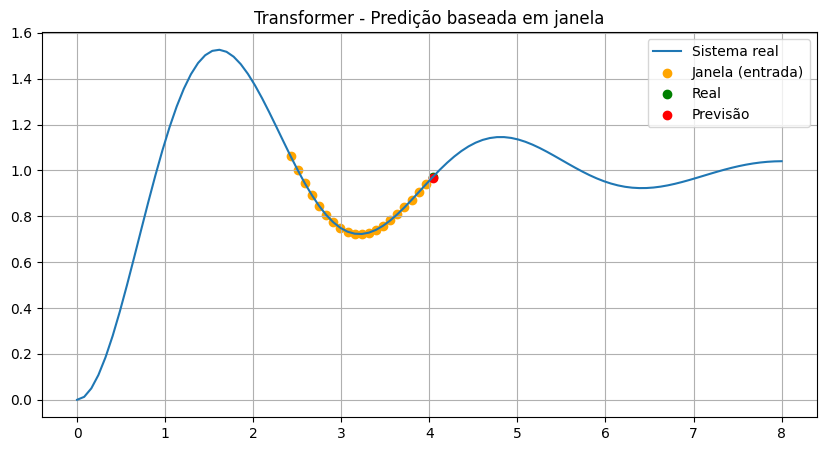

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

# 1) Sistema

t = np.linspace(0, 8, 100).reshape(-1,1)

zeta = 0.2
wn = 2.0
wd = wn * np.sqrt(1 - zeta**2)

y = 1 - (1/np.sqrt(1-zeta**2)) * np.exp(-zeta*wn*t) * np.sin(wd*t + np.arccos(zeta))
y = y.flatten()

# 2) Dataset

def create_dataset(series, window=20):
    X, y = [], []
    for i in range(len(series)-window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    return np.array(X), np.array(y)

window = 20
X_ts, y_ts = create_dataset(y, window)
X_ts = X_ts[..., np.newaxis]

# 3) Split

split_idx = int(0.8 * len(X_ts))

X_train = X_ts[:split_idx]
y_train = y_ts[:split_idx]

X_val = X_ts[split_idx:]
y_val = y_ts[split_idx:]

# 4) Positional Encoding

def positional_encoding(length, d_model):
    pos = np.arange(length)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2*(i//2))/np.float32(d_model))
    angle_rads = pos * angle_rates

    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

    return tf.cast(angle_rads, dtype=tf.float32)

# 5) Transformer Block

def transformer_block(x, d_model, num_heads, dff):
    attn_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=d_model
    )(x, x)

    x = layers.LayerNormalization()(x + attn_output)

    ffn = layers.Dense(dff, activation='relu')(x)
    ffn = layers.Dense(d_model)(ffn)

    x = layers.LayerNormalization()(x + ffn)

    return x

# 6) Modelo

d_model = 32
num_heads = 2
dff = 64

inputs = layers.Input(shape=(window, 1))

x = layers.Dense(d_model)(inputs)
x = x + positional_encoding(window, d_model)

x = transformer_block(x, d_model, num_heads, dff)

x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)

model = tf.keras.Model(inputs, outputs)

model.compile(optimizer='adam', loss='mse')

# 7) Treinamento

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    verbose=0
)

# 8) Predição no treino

pred_train = model.predict(X_train, verbose=0).flatten()

# 9) Rollout

current_window = X_train[-1].flatten()

pred_rollout = []

steps = len(y_ts) - split_idx

for _ in range(steps):
    input_seq = current_window.reshape(1, window, 1)

    next_pred = model.predict(input_seq, verbose=0)[0,0]

    pred_rollout.append(next_pred)

    current_window = np.append(current_window[1:], next_pred)

# 10) Tempo

t_targets = t[window:]

t_train = t_targets[:split_idx]
t_roll = t_targets[split_idx:]
t_split = t_targets[split_idx]

# 11) Plot principal

plt.figure(figsize=(12,6))

plt.plot(t, y, label="Sistema real")

plt.scatter(t[:window+split_idx], y[:window+split_idx], s=15, label="Dados treino")

plt.plot(t_train, pred_train, 'g.', label="Predição treino")

plt.plot(t_roll, pred_rollout, 'm.', label="Transformer (rollout)")

plt.axvline(t_split, linestyle='--', color='k', label="Início extrapolação")

plt.title("Transformer - Ajuste + Extrapolação")
plt.legend()
plt.grid()
plt.show()

# 12) Loss

plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.title("Curva de Loss (Transformer)")
plt.legend()
plt.grid()
plt.show()

# 13) Destaque da janela

idx = 30

plt.figure(figsize=(10,5))

plt.plot(t, y, label="Sistema real")

t_window = t[idx:idx+window]
y_window = y[idx:idx+window]

t_target = t[idx+window]
y_target = y[idx+window]

plt.scatter(t_window, y_window, color='orange', label="Janela (entrada)")
plt.scatter(t_target, y_target, color='green', label="Real")
plt.scatter(t_target, pred_train[idx], color='red', label="Previsão")

plt.title("Transformer - Predição baseada em janela")
plt.legend()
plt.grid()
plt.show()

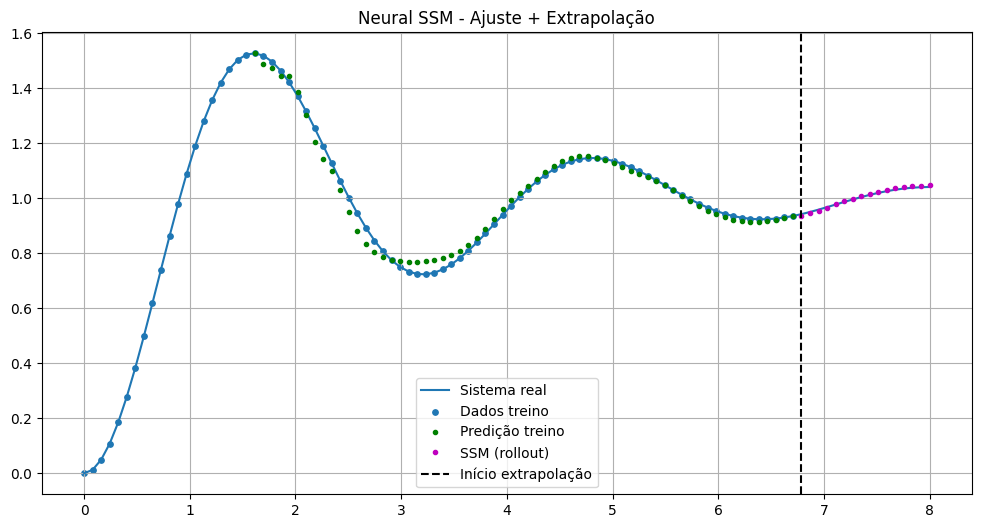

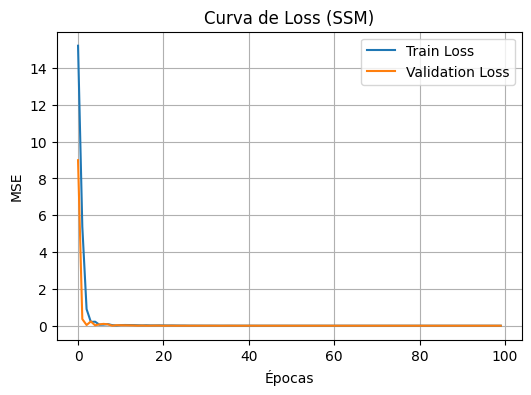

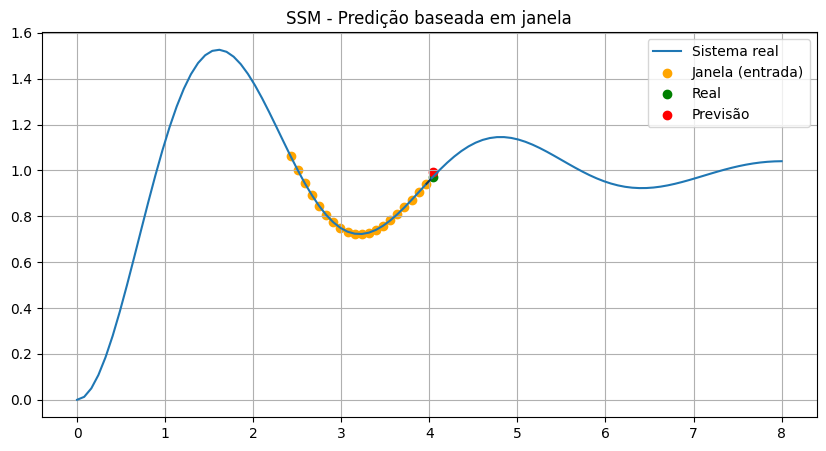

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

# 1) Sistema

t = np.linspace(0, 8, 100).reshape(-1,1)

zeta = 0.2
wn = 2.0
wd = wn * np.sqrt(1 - zeta**2)

y = 1 - (1/np.sqrt(1-zeta**2)) * np.exp(-zeta*wn*t) * np.sin(wd*t + np.arccos(zeta))
y = y.flatten()

# 2) Dataset

def create_dataset(series, window=20):
    X, y = [], []
    for i in range(len(series)-window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    return np.array(X), np.array(y)

window = 20
X_ts, y_ts = create_dataset(y, window)
X_ts = X_ts[..., np.newaxis]

# 3) Split

split_idx = int(0.8 * len(X_ts))

X_train = X_ts[:split_idx]
y_train = y_ts[:split_idx]

X_val = X_ts[split_idx:]
y_val = y_ts[split_idx:]

# 4) Neural SSM

class NeuralSSM(layers.Layer):
    def __init__(self, state_dim=32):
        super().__init__()
        self.state_dim = state_dim

        self.f = tf.keras.Sequential([
            layers.Dense(64, activation='tanh'),
            layers.Dense(state_dim)
        ])

        self.g = tf.keras.Sequential([
            layers.Dense(64, activation='tanh'),
            layers.Dense(1)
        ])

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        time_steps = inputs.shape[1]

        x = tf.zeros((batch_size, self.state_dim))

        for t in range(time_steps):
            u = inputs[:, t, :]
            xu = tf.concat([x, u], axis=-1)
            dx = self.f(xu)
            x = x + dx

        y = self.g(x)
        return y

# 5) Modelo

inputs = layers.Input(shape=(window, 1))
outputs = NeuralSSM()(inputs)

model = tf.keras.Model(inputs, outputs)

model.compile(optimizer='adam', loss='mse')

# 6) Treinamento

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    verbose=0
)

# 7) Predição no treino

pred_train = model.predict(X_train, verbose=0).flatten()

# 8) Rollout

current_window = X_train[-1].flatten()

pred_rollout = []

steps = len(y_ts) - split_idx

for _ in range(steps):
    input_seq = current_window.reshape(1, window, 1)

    next_pred = model.predict(input_seq, verbose=0)[0,0]

    pred_rollout.append(next_pred)

    current_window = np.append(current_window[1:], next_pred)

# 9) Tempo

t_targets = t[window:]

t_train = t_targets[:split_idx]
t_roll = t_targets[split_idx:]
t_split = t_targets[split_idx]

# 10) Plot principal

plt.figure(figsize=(12,6))

plt.plot(t, y, label="Sistema real")

plt.scatter(t[:window+split_idx], y[:window+split_idx], s=15, label="Dados treino")

plt.plot(t_train, pred_train, 'g.', label="Predição treino")

plt.plot(t_roll, pred_rollout, 'm.', label="SSM (rollout)")

plt.axvline(t_split, linestyle='--', color='k', label="Início extrapolação")

plt.title("Neural SSM - Ajuste + Extrapolação")
plt.legend()
plt.grid()
plt.show()

# 11) Loss

plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.title("Curva de Loss (SSM)")
plt.legend()
plt.grid()
plt.show()

# 12) Destaque da janela

idx = 30

plt.figure(figsize=(10,5))

plt.plot(t, y, label="Sistema real")

# janela de entrada
t_window = t[idx:idx+window]
y_window = y[idx:idx+window]

# alvo
t_target = t[idx+window]
y_target = y[idx+window]

# previsão SSM (one-step)
pred_all = model.predict(X_ts, verbose=0).flatten()
y_pred = pred_all[idx]

# plot
plt.scatter(t_window, y_window, color='orange', label="Janela (entrada)")
plt.scatter(t_target, y_target, color='green', label="Real")
plt.scatter(t_target, y_pred, color='red', label="Previsão")

# linha didática
plt.plot([t_window[-1], t_target],
         [y_window[-1], y_target],
         'k--', alpha=0.5)

plt.title("SSM - Predição baseada em janela")
plt.legend()
plt.grid()
plt.show()

Epoch 0, Loss: 1.030089
Epoch 1000, Loss: 0.097859
Epoch 2000, Loss: 0.095407
Epoch 3000, Loss: 0.094524
Epoch 4000, Loss: 0.080477
Epoch 5000, Loss: 0.008391
Epoch 6000, Loss: 0.006951
Epoch 7000, Loss: 0.037210
Epoch 8000, Loss: 0.002158


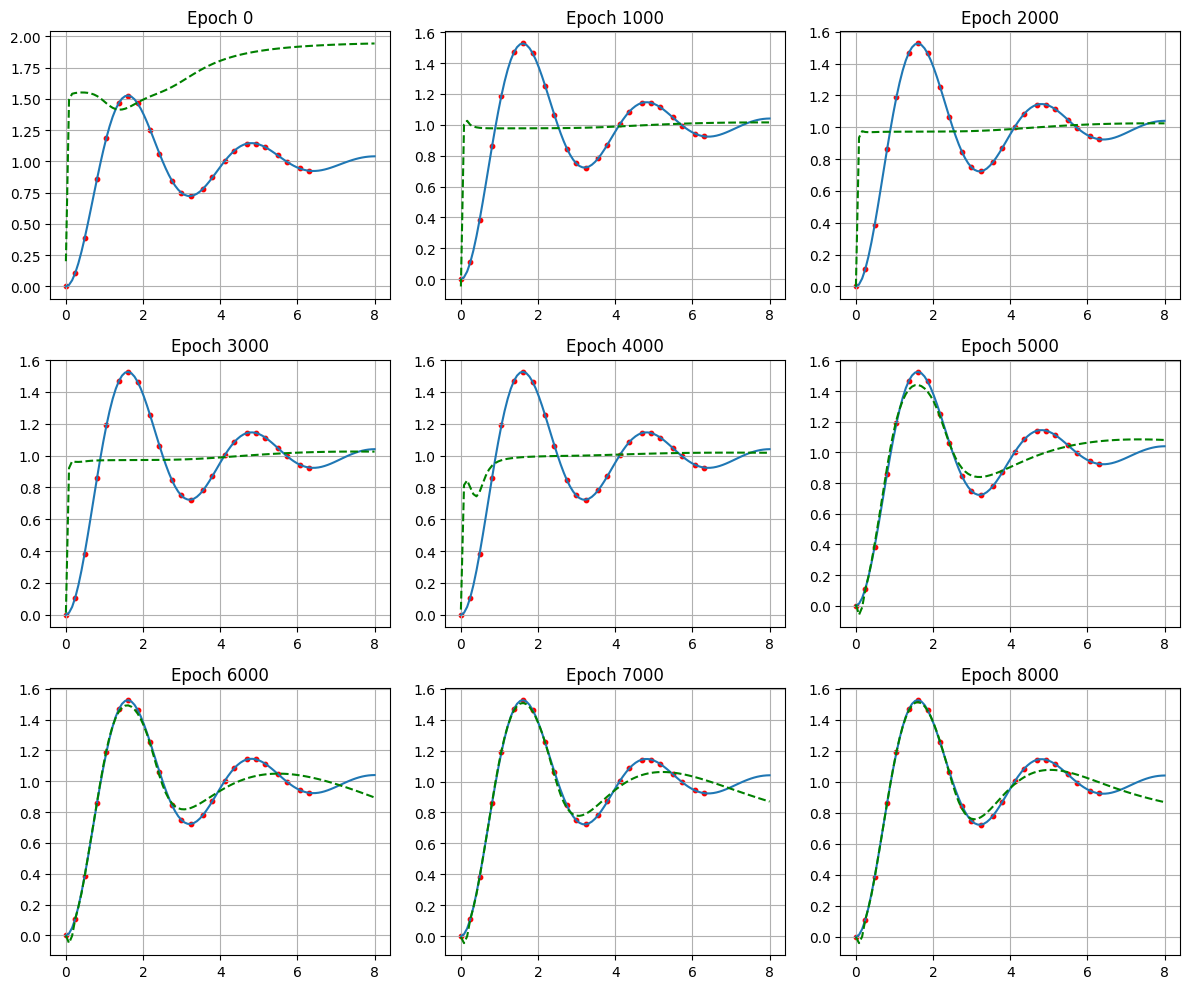

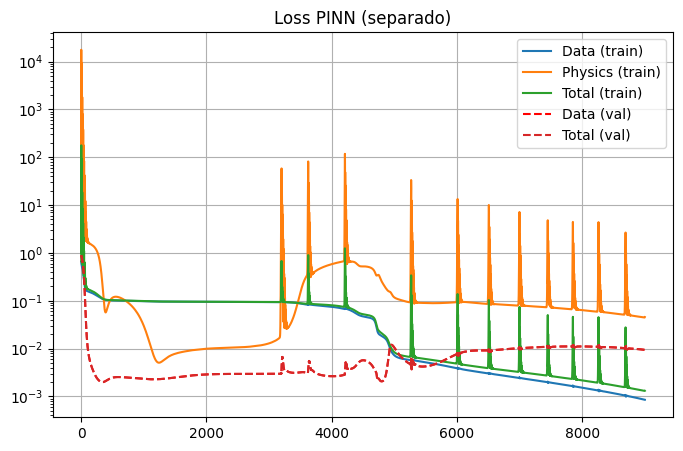

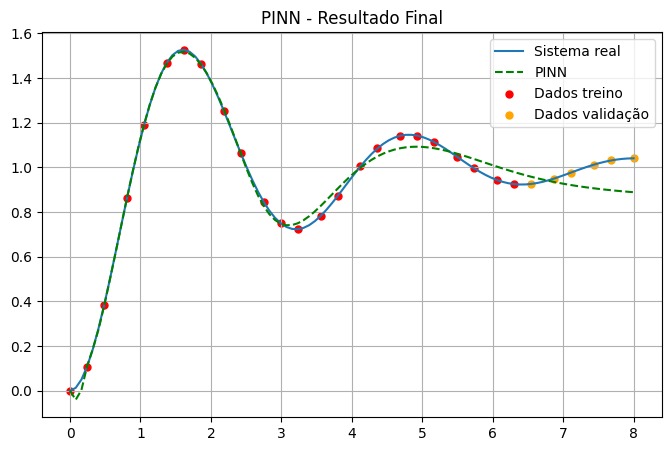

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# 1) Sistema

t = np.linspace(0, 8, 100).reshape(-1,1).astype(np.float32)

zeta = 0.2
wn = 2.0

wd = wn * np.sqrt(1 - zeta**2)

y = 1 - (1/np.sqrt(1-zeta**2)) * np.exp(-zeta*wn*t) * np.sin(wd*t + np.arccos(zeta))

# 2) Dados (treino / validação)

idx = np.linspace(0, 99, 30).astype(int)

x_all = t[idx]
y_all = y[idx]

# split manual
split_data = int(0.8 * len(x_all))

x_data = tf.convert_to_tensor(x_all[:split_data], dtype=tf.float32)
y_data = tf.convert_to_tensor(y_all[:split_data], dtype=tf.float32)

x_val = tf.convert_to_tensor(x_all[split_data:], dtype=tf.float32)
y_val = tf.convert_to_tensor(y_all[split_data:], dtype=tf.float32)

# 3) Pontos físicos

x_phys = tf.linspace(0.0, 8.0, 50)
x_phys = tf.reshape(x_phys, (-1,1))

# 4) Rede

class My_NN(tf.Module):
    def __init__(self):
        self.W1 = tf.Variable(tf.random.normal([1, 32]))
        self.b1 = tf.Variable(tf.zeros([32]))
        self.W2 = tf.Variable(tf.random.normal([32, 32]))
        self.b2 = tf.Variable(tf.zeros([32]))
        self.W3 = tf.Variable(tf.random.normal([32, 8]))
        self.b3 = tf.Variable(tf.zeros([8]))
        self.W4 = tf.Variable(tf.random.normal([8, 1]))
        self.b4 = tf.Variable(tf.zeros([1]))

    def __call__(self, x):
        h1 = tf.nn.tanh(tf.matmul(x, self.W1) + self.b1)
        h2 = tf.nn.tanh(tf.matmul(h1, self.W2) + self.b2)
        h3 = tf.nn.tanh(tf.matmul(h2, self.W3) + self.b3)
        return tf.matmul(h3, self.W4) + self.b4

model = My_NN()

# 5) Treinamento

optimizer = tf.optimizers.Adam(learning_rate=0.001)

epochs = 9000

# histórico
loss_data_train = []
loss_phys_train = []
loss_total_train = []

loss_data_val = []
loss_total_val = []

# figuras
fig, axes = plt.subplots(3,3, figsize=(12,10))
axes = axes.flatten()
plot_idx = 0

for epoch in range(epochs+1):

    with tf.GradientTape() as tape:

        # DATA LOSS
        yh = model(x_data)
        data_loss = tf.reduce_mean(tf.square(yh - y_data))

        # PHYSICS LOSS
        with tf.GradientTape() as t2:
            t2.watch(x_phys)
            with tf.GradientTape() as t1:
                t1.watch(x_phys)
                yhp = model(x_phys)
            dy = t1.gradient(yhp, x_phys)
        d2y = t2.gradient(dy, x_phys)

        physics = d2y + 2*zeta*wn*dy + (wn**2)*yhp - (wn**2)
        physics_loss = tf.reduce_mean(tf.square(physics))

        total_loss = data_loss + 0.01*physics_loss

    grads = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    # validação

    yh_val = model(x_val)
    data_loss_val = tf.reduce_mean(tf.square(yh_val - y_val))

    total_loss_val = data_loss_val  # sem física aqui

    # histórico

    loss_data_train.append(data_loss.numpy())
    loss_phys_train.append(physics_loss.numpy())
    loss_total_train.append(total_loss.numpy())

    loss_data_val.append(data_loss_val.numpy())
    loss_total_val.append(total_loss_val.numpy())

    # plots intermediários

    if epoch % 1000 == 0 and plot_idx < 9:

        y_pred = model(tf.convert_to_tensor(t)).numpy()

        ax = axes[plot_idx]
        ax.plot(t, y, label="Real")
        ax.plot(t, y_pred, 'g--', label="PINN")
        ax.scatter(x_data, y_data, color='red', s=10)

        ax.set_title(f"Epoch {epoch}")
        ax.grid()

        plot_idx += 1

        print(f"Epoch {epoch}, Loss: {total_loss.numpy():.6f}")

plt.tight_layout()
plt.show()

# 6) Curvas de Loss

plt.figure(figsize=(8,5))

# treino
plt.plot(loss_data_train, 'b-', label="Data (train)")
plt.plot(loss_phys_train, 'r-', label="Physics (train)")
plt.plot(loss_total_train, 'g-', label="Total (train)")

# validação
plt.plot(loss_total_val, 'm--', label="Total (val)")

plt.yscale('log')
plt.title("Loss PINN (separado)")
plt.legend()
plt.grid()
plt.show()

# Predição final

y_pred = model(tf.convert_to_tensor(t)).numpy()

# Plot final

plt.figure(figsize=(8,5))

plt.plot(t, y, label="Sistema real")

plt.plot(t, y_pred, 'g--', label="PINN")

plt.scatter(x_data, y_data, color='red', s=25, label="Dados treino")
plt.scatter(x_val, y_val, color='orange', s=25, label="Dados validação")

plt.title("PINN - Resultado Final")
plt.legend()
plt.grid()

plt.show()

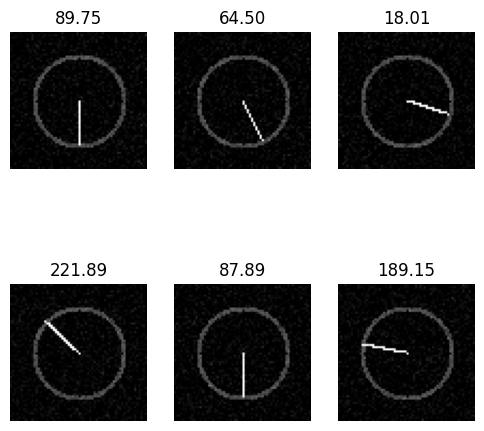

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def generate_pointer_image(size=64, angle=0):
    img = np.zeros((size, size))

    center = size // 2
    radius = size // 3

    # círculo (opcional, só visual)
    for i in range(size):
        for j in range(size):
            dist = np.sqrt((i-center)**2 + (j-center)**2)
            if abs(dist - radius) < 1:
                img[i,j] = 0.3

    # ponteiro
    x_end = int(center + radius * np.cos(angle))
    y_end = int(center + radius * np.sin(angle))

    num_points = 100
    xs = np.linspace(center, x_end, num_points)
    ys = np.linspace(center, y_end, num_points)

    for x, y in zip(xs, ys):
        xi, yi = int(x), int(y)
        if 0 <= xi < size and 0 <= yi < size:
            img[yi, xi] = 1.0

    # ruído leve
    img += 0.05*np.random.randn(size, size)

    return np.clip(img, 0, 1)

# gerar dataset
N = 2000
size = 64

X = []
y = []

for _ in range(N):
    angle = np.random.uniform(0, 2*np.pi)
    img = generate_pointer_image(size, angle)

    X.append(img)
    y.append(angle)

X = np.array(X)[..., np.newaxis]
y = np.array(y)

# visualizar exemplos
plt.figure(figsize=(6,6))
for i in range(2*3):
    plt.subplot(2,3,i+1)
    plt.imshow(X[i].squeeze(), cmap='gray')
    plt.title(f"{(180*y[i]/np.pi):.2f}")
    plt.axis('off')
plt.show()

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step - loss: 0.0486 - val_loss: 0.0027
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - loss: 0.0014 - val_loss: 9.4306e-04
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - loss: 6.0306e-04 - val_loss: 5.3389e-04
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - loss: 3.6676e-04 - val_loss: 3.5871e-04
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - loss: 3.2219e-04 - val_loss: 3.1706e-04
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - loss: 3.0067e-04 - val_loss: 2.8335e-04
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - loss: 2.6792e-04 - val_loss: 3.3541e-04
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - loss: 2.5871e-04 - val_loss: 2.7765e-04
Epoch 9/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - loss: 2.6315e-04 - val_loss: 2.8537e-04
Epoch 10/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 2.4125e-04 - val_loss: 2.2697e-04


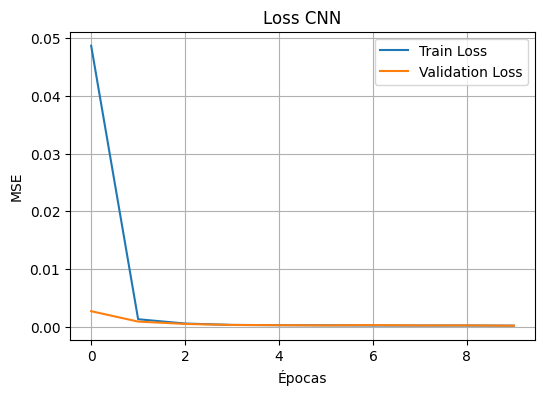

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


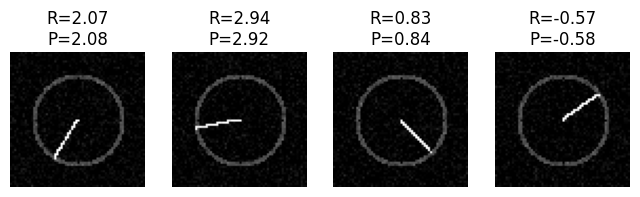

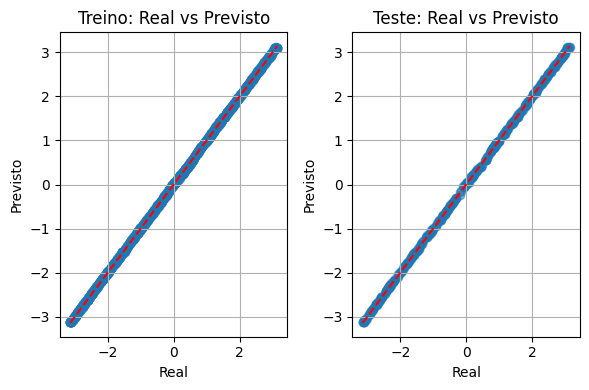

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

# 1) Dados sintéticos

def generate_pointer_image(size=64, angle=0):
    img = np.zeros((size, size))

    center = size // 2
    radius = size // 3

    # círculo
    for i in range(size):
        for j in range(size):
            dist = np.sqrt((i-center)**2 + (j-center)**2)
            if abs(dist - radius) < 1:
                img[i,j] = 0.3

    # ponteiro
    x_end = int(center + radius * np.cos(angle))
    y_end = int(center + radius * np.sin(angle))

    xs = np.linspace(center, x_end, 100)
    ys = np.linspace(center, y_end, 100)

    for x, y in zip(xs, ys):
        xi, yi = int(x), int(y)
        if 0 <= xi < size and 0 <= yi < size:
            img[yi, xi] = 1.0

    # ruído
    img += 0.05*np.random.randn(size, size)

    return np.clip(img, 0, 1)

# gerar dataset
N = 2000
size = 64

X = []
y = []

for _ in range(N):
    angle = np.random.uniform(0, 2*np.pi)
    img = generate_pointer_image(size, angle)

    X.append(img)
    y.append([np.cos(angle), np.sin(angle)])  # saída vetorial

X = np.array(X)[..., np.newaxis]
y = np.array(y)

# 2) Split treino/teste

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3) Modelo CNN

model = tf.keras.Sequential([
    layers.Conv2D(16, 3, activation='relu', input_shape=(64,64,1)),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(2)  # cos, sin
])

model.compile(optimizer='adam', loss='mse')

# 4) Treinamento

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    verbose=1
)

# 5) Curva de Loss

plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.title("Loss CNN")
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.legend()
plt.grid()
plt.show()

# 6) Predições

pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

# converter para ângulo
theta_train_real = np.arctan2(y_train[:,1], y_train[:,0])
theta_train_pred = np.arctan2(pred_train[:,1], pred_train[:,0])

theta_test_real = np.arctan2(y_test[:,1], y_test[:,0])
theta_test_pred = np.arctan2(pred_test[:,1], pred_test[:,0])

# 7) Visualização de exemplos

plt.figure(figsize=(8,3))
for i in range(2*2):
    plt.subplot(1,4,i+1)
    plt.imshow(X_test[i].squeeze(), cmap='gray')
    plt.title(f"R={theta_test_real[i]:.2f}\nP={theta_test_pred[i]:.2f}")
    plt.axis('off')
plt.show()

plt.figure(figsize=(6,4))
plt.subplot(1,2,1)
plt.scatter(theta_train_real, theta_train_pred, alpha=0.5)# Scatter treino
plt.plot([-np.pi, np.pi], [-np.pi, np.pi], 'r--')
plt.title("Treino: Real vs Previsto")
plt.xlabel("Real")
plt.ylabel("Previsto")
plt.grid()

plt.subplot(1,2,2)
plt.scatter(theta_test_real, theta_test_pred, alpha=0.5) #Scatter teste
plt.plot([-np.pi, np.pi], [-np.pi, np.pi], 'r--')
plt.title("Teste: Real vs Previsto")
plt.xlabel("Real")
plt.ylabel("Previsto")
plt.grid()
plt.tight_layout()
plt.show()